<a href="https://colab.research.google.com/github/GermanAlmanza14/Econometria_con_Python/blob/main/OLS_simple01_CEOSAL1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


### License: Creative Commons Attribution 4.0 International (CC BY 4.0)
This work is licensed under a [Creative Commons Attribution 4.0 International License](https://creativecommons.org/licenses/by/4.0/).
<br>

```
   )
  ((
([__])p
```
<br>
© 2026 Germán Almanza

ralmanza@uacj.mx


# **Ejemplo 2.3: Salario de los CEO (salary) y Tasa de Retorno de la empresa (reo)**

Analizaremos los ejemplos de Wooldridge, para nuestra fortuna en python existe un paquete que contiene todas las bases de datos del texto de Wooldridge.
Por lo tanto,  necesitamos instalar el
Python package [wooldridge](https://github.com/spring-haru/wooldridge).
La instrucción para instalar paquetes en python es `!pip install`, introducimos esta instrucción en una celda de código.

Thaks to Tetsu HARUYAMA avec [spring-haru](https://github.com/spring-haru).

In [ ]:
#     Instala el paquete de 'wooldridge' que nos comparte  spring-haru

!pip install wooldridge

## **1. Cargar base de datos**

  Una vez instalado el paquete `wooldridge`, en una celda de código importamos el paquete y cargamos/leemos la base de datos de interés.

In [ ]:
import wooldridge as woo

ceosal1=woo.dataWoo('ceosal1')
ceosal1


 <br>


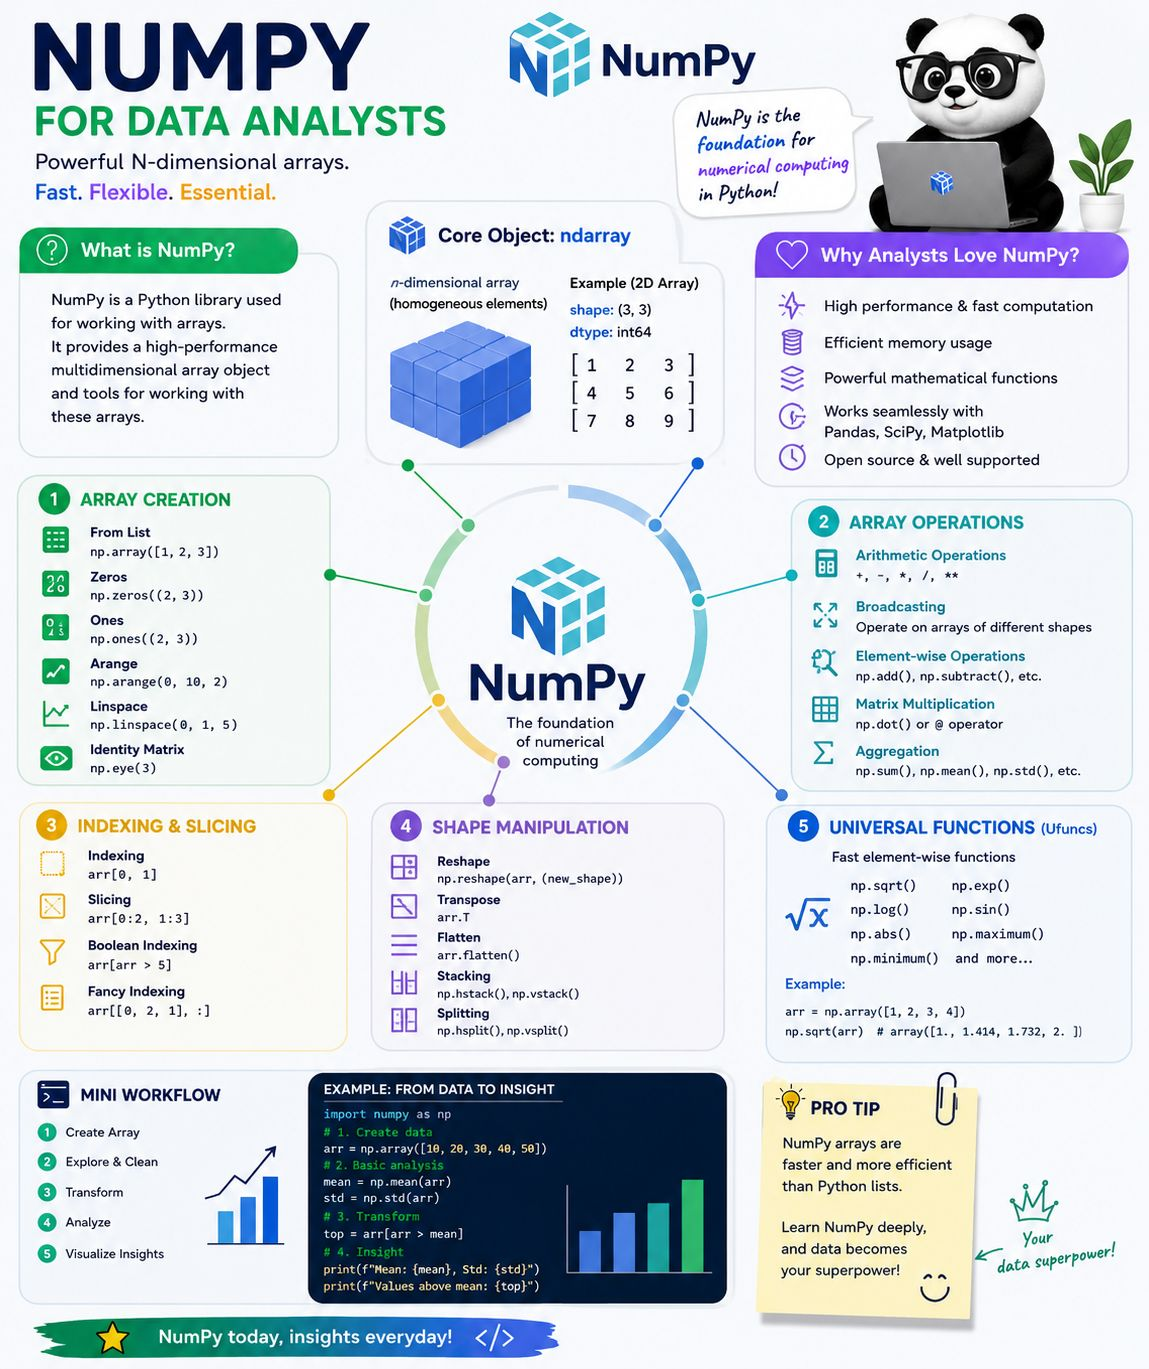

## **2. Descripción básica de variables**

La paqueteria `numpy` nos permite realizar cálculos matemáticos y realizar operaciones con arreglos (array) o matrices de datos. Enseguida realizamos operaciones básicas como la media, el máximo y mínimo de un arreglo de datos.


 <br>


In [ ]:
import numpy as np

salario=ceosal1['salary']
salario_prm=np.mean(salario)
salario_max=max(salario)
salario_min=min(salario)

roe=ceosal1['roe']
roe_prm=np.mean(roe)
roe_max=max(roe)
roe_min=min(roe)

#     '{salario_prm*100:.2f}' toma la variable y multiplica por 100, 2-decimales
print(f'El salario promedio es: ${salario_prm*1000:,.2f}')
print(f'El salario más bajo es: ${salario_min*1000:,.2f}')
print(f'El salario más alto es: ${salario_max*1000:,.2f}\n')
#     '{salario_prm*100:.2f}' toma la variable y multiplica por 100, 2-decimales
print(f'El promedio de rendimiento de capital es: {roe_prm:.2f}%')
print(f'El rendimiento de capital más bajo es: {roe_min:,.2f}%')
print(f'El rendimiento de capital más alto es: {roe_max:,.2f}%')




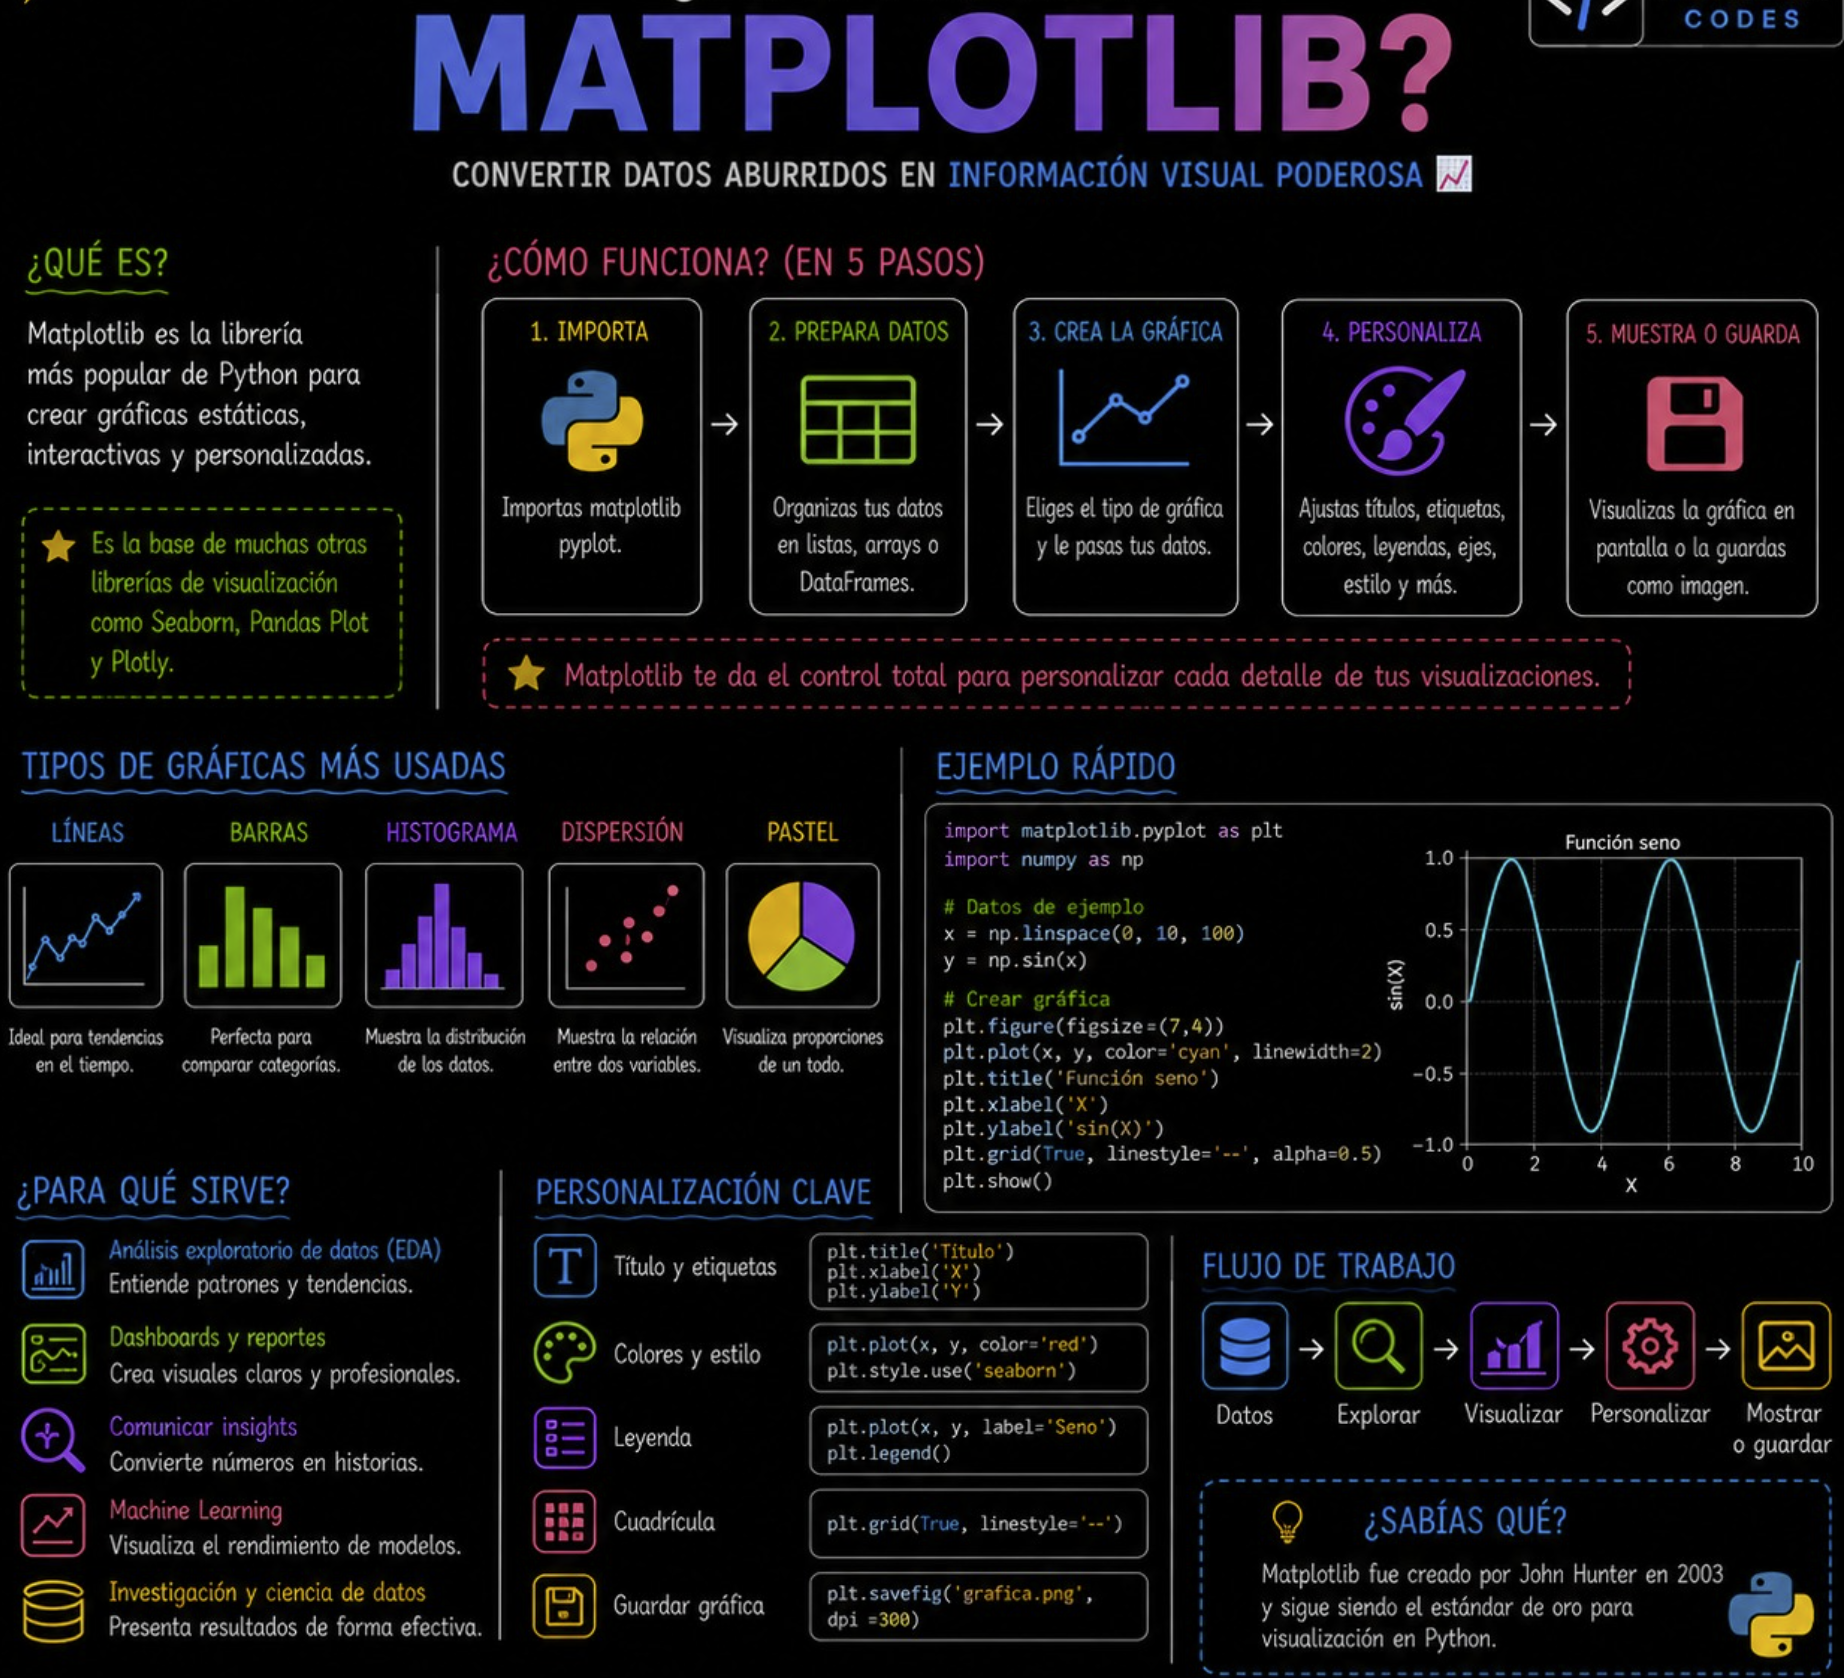

###   **Gráfica de datos: histograma**

El paquete `matplotlib` lo utilizamos para graficar datos, enseguida algunas opciones para los gráficos:



*   [matplolib colors](https://matplotlib.org/stable/gallery/color/named_colors.html)
*   [matplotlib markers](https://matplotlib.org/stable/api/markers_api.html)




In [ ]:
import matplotlib.pyplot as plt

# Histograma :
plt.hist(roe,color='pink')
plt.ylabel('Frecuencia')
plt.xlabel('Tasa de retorno')
plt.title('mi primer histograma en python')
plt.savefig('Histograma1.jpeg')
plt.show()

In [ ]:
import statsmodels.api as sm

# estimate kernel density:
kde=sm.nonparametric.KDEUnivariate(roe)
kde.fit()

plt.plot (kde.support,kde.density, color='b', linewidth=1)
plt.ylabel('densidad')
plt.xlabel('roe')
plt.title('mi primer CDF en python')

plt.savefig('Densidad1.jpg')
plt.show()

In [ ]:
# subfigure b (kernel density with overlayed histogram) :
plt.hist(roe, color='cornflowerblue', density=True)
plt.plot(kde.support,kde.density, color='black', linewidth=2)
plt.ylabel('densidad')
plt.xlabel('roe')
plt.savefig('Density2.pdf')

## **3. Medidas de tendencia central**

### **Funciones de estadística con numpy**
Principales funciones de Estadística Descriptiva incluidas en el modulo ```numpy```

* ```np.mean(x)```          media aritmetica   $\bar X=\tfrac{1}{n}\sum_{i=1}^nx_i$

* ```np.median(x)```        mediana

* ```np.var(x,ddof=1)```    varianza            $s_x^2=\tfrac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)^2$

* ```np.std(x,ddof=1)```           desviación estandar $s_x=\sqrt{s_x^2}$

* ```np.cov(x,y)```         covarianza          $s_{xy}=\tfrac{1}{n-1}\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)$

* ```np.corrcoef(x,y)```    coeficiente de correlación de Pearson   

\begin{align}
r_{xy}&=\frac{\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)}
{\sqrt{\sum_{i=1}^n(x_i-\bar x)^2}\sqrt{\sum_{i=1}^n(y_i-\bar y)^2}}\\
&=\frac{S_{xy}}{S_x\cdot S_y}\\
&=\frac{cov(x,y)}{var(x)\cdot var(y)}
\end{align}

<br>
<br>

### **Observación:**
Hemos denotado $S_x^2$ y $S_x$ a la varianza y desviación estandar **muestrales**, respectivamente. En estas fórmulas el denominador es $n-1$ en lugar de $n$, que se utiliza para definir los mismos estadísticos  **poblacionales**

*  ```np.var(x,ddof=0)```    varianza            $\sigma_x^2=\tfrac{1}{n}\sum_{i=1}^n(x_i-\bar x)^2$

* ```np.std(x,ddof=0)```           desviación estandar $\sigma_x=\sqrt{s_x^2}$

Para evitar el sesgo en los estadísticos muestrales es necesario introducir el denominador $n-1$, este término se conoce como [corrección de Bessel](https://en.wikipedia.org/wiki/Bessel%27s_correction). En python es necesario agregar la opción ```ddof=1``` para obtener la varianza y desviación estandar en las funciones como se señala arriba.

In [ ]:
import numpy as np

#    variable x
roe=ceosal1['roe']  # ROE : rate of equity / tasa de retorno
#    variable y
salario=ceosal1['salary']

#    Estadisticos del modelo
med_roe=np.mean(roe)
med_sal=np.mean(salario)
var_roe=np.var(roe,ddof=1)
var_sal=np.var(salario,ddof=1)
std_sal=np.std(salario,ddof=1)
std_roe=np.std(roe,ddof=1)
#
cov=np.cov(roe,salario)[0,1]

#     Resultado de estadisticos
print(f'Media de salario:${med_sal:,.2f}')
print(f'Varianza de salario:{var_sal:,.2f}')
print(f'Desviación Estandar de salario:{std_sal:,.2f}\n')

print(f'Media de roe:{med_roe:.2f}%')
print(f'Varianza de roe:{var_roe:.2f}')
print(f'Desviación Estandar de roe:{std_roe:,.2f}\n')

#      Covarianza
print(f'Covarianza Cov(s-r):{cov:.2f}')



## **4. Estimadores de OLS/MCO**

En el <mark>modelo de regresión lineal simple</mark>
$$y=\beta_0+\beta_1 x+u,$$
la variable observada $y$ es explicada por la variable $x$, el término $u$ es el factor de error y  el método de MCO estima  los coeficientes $\beta_0$ y $\beta_1$.

La <mark>línea de regresión OLS</mark> esta definida por la ecuación
$$\hat y=\hat\beta_0+\hat\beta_1 x.$$
Llamamos <mark>estimadores de OLS</mark> a los
términos $\hat y,\;\hat\beta_0$ y $\hat\beta_1$, los coeficientes de $\hat y$ en términos de estadísticos los representamos de la siguiente manera
\begin{align}
\hat\beta_0&=\bar y-\beta_1\bar x,\\
\hat\beta_1&=\frac{\sum_{i=1}^nx_i(y_i-\bar y)}{\sum_{i=1}^nx_i(x_i-\bar x)}.\\
\end{align}

Observe que [**TAREA: demostrar la siguiente identidad**]
$$\begin{align}
\frac{\sum_{i=1}^nx_i(y_i-\bar y)}{\sum_{i=1}^nx_i(x_i-\bar x)}
&=\frac{\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)}{\sum_{i=1}^n(x_i-\bar x)^2}\\
&=\frac{cov(x,y)}{var(x)}\qquad(1\star)\\
\end{align}$$
por lo tanto

\begin{align}
\hat\beta_0&=\bar y-\beta_1\bar x\qquad\hspace{.4cm} 1\heartsuit\\
\hat\beta_1&=\frac{cov(x,y)}{var(x)}\qquad 2\heartsuit\\
\end{align}


Las ecuaciones $(1\heartsuit)$ y $( 2\heartsuit)$, son las ecuaciones  (2.17) y (2.19) en  (Wooldridge 2010).


In [ ]:
#   Estimadores de OLS

Beta1=cov/var_roe
Beta0=med_sal-med_roe*Beta1

print(f'Estimador de Beta0:{Beta0:.3f}')
print(f'Estimador de Beta1:{Beta1:.3f}')

### **IPython.display**

Hasta este momento hemos utilizado la función `print()` para presentar o mostrar resultados de calculos realizados, esta función presenta lo que se conoce como "texto plano". El resultado anterior son los estimadores de MCO, si queremos presentar estos resultados en términos de los estadísticos, como en las ecuaciones $(\heartsuit)$  es necesario agregar el modulo `IPython.display`, este módulo combina el lenguaje [LaTeX](https://es.overleaf.com/learn/latex/Mathematical_expressions) con las variables obtenidas en `python` mediante la función-f `print(f'{variable}')`. En print la variable se introduce entre corchetes '{}', con la función `display` además hay que agregar otro par de corchetes '{}'; es decir, '{{variable}}'. Enseguida un ejemplo.

In [ ]:
from IPython.display import Math, display, Markdown

# Formato LaTeX en celda de codigo
display(Markdown(rf"$\beta_1 = \frac{{{cov:.2f}}}{{{var_roe:.2f}}} = {Beta1:.3f}$"))
display(Markdown(rf"$\beta_0 = {med_sal:.2f}-({med_roe:.2f})({Beta1:.2f}) = {Beta0:.3f}$"))

### **Ecuación de regresión lineal**

Con los valores estadísticos anteriores, tenemos la **ecuación de regresión lineal**
$$\widehat{salario}=963.191+18.501*roe$$

## **5. OLS con `statsmodels`**

La paquetería [`statsmodels` ](https://www.statsmodels.org/stable/index.html)  proporciona funciones para realizar diversos modelos estadísticos, su estilo está inspirado en el lenguaje de programación R. Aquí lo utilizaremos para realizar la estimación de MCO con la función `.ols(,data)`.

Después de agregar este modulo, es necesario definir la base de datos con la que vamos a trabajar, esto ya lo hicimos en el primer apartado "1. Cargar base de datos" esto lo indicamos en la linea-3 solo para que no ocurran errores, posteriormente definimos la variable "reg1" que va a guardar los resultados de la estimación de OLS y la función `.summary()` presenta los resultados.


In [ ]:
import statsmodels.formula.api as stf

ceosal1=woo.dataWoo('ceosal1')
reg1=stf.ols('salary ~ roe',data=ceosal1).fit()

# Muestra el resumen o resultado de la regresion
reg1.summary()

### **Interpretación de los estadísticos de MCO**


Llamamos **función de regresión muestral (FRM)** o ecuación de estimación a la expresión

$$\widehat{salario}=963.191+18.501*roe.\qquad(\clubsuit)$$

La interpretación de esta ecuación es simple, observe que $\widehat{salario}$ cuyas unidades son en miles de dlls, esta determinado linealmente en términos de $roe$ que sus unidades son valores porcentuales. Por lo tanto, si la tasa de retorno $roe=0$, el salario del CEO es \$963,191.00 dlls; por otra parte, $\hat\beta_1=18.501$ denota la **variación marginal** del salario respecto a cambio en $roe$ y esto se denota como
$$\Delta\widehat{salario}=18.501*(\Delta roe).$$

Por lo tanto, si la tasa de retorno incrementa en 1\% (la unidad de $roe$ son puntos porcentuales), se estima un incremento en el salario de \$18,501 dlls, esto es independiente del salario inicial del CEO.

<br>


In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
#   Grafica los 'puntos' que definen las variables
plt.plot('roe','salary',data=ceosal1,color='g',marker='o',linestyle='',label='roe-salary')
#   Grafica la 'recta de ajuste'
plt.plot(ceosal1['roe'],reg1.fittedvalues,color='red',linestyle='-',label='linea de ajuste')
plt.ylabel ('salario')
plt.xlabel ('roe')
#   titulo
plt.title(r'$\widehat{salario}$'f'={Beta0:.3f}+{Beta1:.3f}*roe', size=14)
plt.legend()
plt.savefig('Regresion1.jpg')

plt.show()

### **Estimación lineal (*forecasting*)**




[Paul Samuelson](https://infinite.mit.edu/video/paul-samuelson/) nos advierte:

> "Algunos de nuestros mejores **economistas parecen ser bastante malos pronosticadores** del futuro.
De hecho, uno de nuestros mejores economistas ni siquiera pudo prever correctamente los resultados de las últimas elecciones. ¿Es legítimo preguntarle a un académico: "Si eres tan científico y erudito, ¿cómo es que eres tan estúpido prediciendo el PNB del año que viene?".
 [Samuelson (1967)](https://alumnosuacj-my.sharepoint.com/:b:/g/personal/ralmanza_uacj_mx/EbE4PmrhhmdDviJPhdlKpYABmyBEjz_YHbn99Aw9MEt5yQ?e=ezd3mm)

<br>

La ecuación de estimación $(\clubsuit)$
con frecuencia y bajo condiciones de "regularidad" se utiliza para hacer estimaciones de valores originalmente desconocidos, a ésto suele llamarse "pronóstico estadístico", yo prefiero el verbo "estimar", porque es lo que hacemos en estadística. Explicaremos esto con la siguiente función de estimación.






In [ ]:
def Y(x):
    return Beta0+Beta1*x

valores=np.array([10, 20, 30, 40, 50])
estimado=np.array([Y(val) for val in valores])

for est in estimado:
    print(f'{est:.2f}')
#Y(1)

In [ ]:
plt.figure(figsize=(8,5))

plt.plot('roe','salary',data=ceosal1,color='g',marker='o',linestyle='',label='roe')
plt.plot(ceosal1['roe'],reg1.fittedvalues,color='red',linestyle='-',label='regresión')
plt.plot(valores,estimado,color='b',marker='*',linestyle='',label='valor estimado',  markersize=10)

plt.ylabel ('salario')
plt.xlabel ('roe')
#   titulo
plt.title(r'$\widehat{salario}$'f'={Beta0:.3f}+{Beta1:.3f}*roe', size=14)
plt.legend()
plt.savefig('Regresion2b.jpg')

plt.show()

## **6. Coeficiente de Correlación de Pearson**

<br>

Hemos definido **el coeficiente de correlación de Pearson** como

<br>

\begin{equation}
r_{xy}=\frac{\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)}
{\sqrt{\sum_{i=1}^n(x_i-\bar x)^2}\sqrt{\sum_{i=1}^n(y_i-\bar y)^2}}=\frac{cov(x,y)}{s_x\cdot s_y}.\end{equation}

<br>


**Observación 1:**
*  $cov(x,y)$ es una medida de la variabilidad conjunta de las variables aleatorias $x$ y $y$, el signo de la covarianza muestra la tendencia en la relación lineal de estas variables.
Si $cov(x,y)>0$, entonces  las variables tienen un comportamiento similar; es decir, si $x$ aumenta, también aumenta $y$. En caso contrario,  si $cov(x,y)< 0$, diremos que la relación entre las variables es inversa; es decir, si $x$ aumenta, $y$ disminuye.

* $var(x)=cov(x,x)$ es una medida de disperción, que nos muestra que tan distante se encuentra la variable $x$ de su media $\bar x$. Por otra parte, recuerda que $\bar x= E(x)$, es decir, la media es el valor esperado de $x$. Por esta razón, se suele decir que <mark>la varianza mide el riesgo de $x$</mark>.

<br>

**Observación 2:**
En `python` la covarianza la calculamos con la función `np.cov(x,y)`, que nos devuelve <mark>la matriz de varianza-covarianza</mark>, esta es una matriz que muestra la combinación del producto de las variables, dado que $cov(x,y)=cov(y,x)$, la matriz es simétrica y con $var(x)$ y $var(y)$ en la diagonal. Si solo nos interesa el valor de $cov(x,y)$ debemos hacer la siguiente instrucción


```
np.cov(x,y)[0,1]
```

In [ ]:
#  Matrix de Varianza-Covarianza salario-roe
cov_sr=np.cov(salario,roe,rowvar=False)
cov_sr
print(cov_sr)

In [ ]:
#   Covarianza salario-roe
cov_sr=np.cov(salario,roe)[0,1]
cov_sr

### **Una nota de Álgebra lineal**

En álgebra lineal sabemos que del [producto punto](https://en.wikipedia.org/wiki/Dot_product)
de los vectores $X$ y $Y$, se deduce la siguiente identidad
$$X\cdot Y=\|X\|\|Y\|\cos\theta
\qquad \Rightarrow\qquad
\cos\theta=\frac{X\cdot Y}{\|X\|\|Y\|},$$
donde $\theta$ es el ángulo entre los vectores.

<br>

Recuerde además que **la norma de un vector** esta definida como
$$\|X\|=\sqrt{x_1^2+x_2^2+\dots+x_k^2},$$
por lo tanto
$$r_{xy}=
\frac{\sum_{i=1}^n(x_i-\bar x)(y_i-\bar y)}
{\sqrt{\sum_{i=1}^n(x_i-\bar x)^2}\sqrt{\sum_{i=1}^n(y_i-\bar y)^2}}
=\frac{X\cdot Y}{\|X\|\|Y\|}
=\cos\theta,\qquad(1\spadesuit)$$
para
$$X=[(x_1-\bar x),(x_2-\bar x),\dots,(x_n-\bar x)]\quad\text{y}\quad
Y=[(y_1-\bar y),(y_2-\bar y),\dots,(y_n-\bar y)].
$$

La identidad anterior muestra que el coeficiente de correlación de Pearson determina el coseno del ángulo entre los vectores $X$ y $Y$; esto significa que

$$-1\leq r_{xy}\leq 1.\qquad (2\spadesuit)$$


De lo anterior, sigue que **la relación entre las variables** $x$ y $y$ es

* **proporcional**: <mark>cuando $r_{xy}$ toma valor cercano a 1</mark>; por lo tanto, si $x$ incrementa, también $y$ incrementa (y viceversa).

* **inversa**: para valores de $r_{xy}$  cercanos a -1; de modo que, si $x$ aumenta, entonces $y$ disminuye (y viceversa).

* **nula**: para valores de $r_{xy}$ cerca de cero.


<br>

En términos matemáticos, el coeficiente de correlación de Pearson $r_{xy}$ es una **normalización** de la covarianza; esto significa, que su  valor absoluto esta entre 0 y 1.


### **scipy.stats**

[scipy.stats](https://docs.scipy.org/doc/scipy/reference/stats.html) es una paquetería de `python` que contiene muchas funciones y pruebas estadísticas, aquí la utilizamos solo para calcular el coeficiente de Pearson `pearsonr(x,y)[0]`.

[numpy](https://numpy.org/doc/stable/index.html), tiene la función `.corrcoef()` que muestra la "normalización" de la matriz varianza-covarianza, de modo nos interesa únicamente el coeficiente de correlación de Pearson a esta función debemos señalar el elemento de interés en la matriz; es decir, `.corrcoef(x,y)[0,1]`


 también tiene una función para obtener este valor y es

In [ ]:
from IPython.display import Math, display, Markdown
from scipy.stats import pearsonr

#   Coef Corr de Pearson: fórmula
pear_sr=cov_sr/(std_sal*std_roe)
# Formato LaTeX en celda de codigo
display(Markdown(rf"$r_{{sr}} = \frac{{{cov_sr:.2f}}}{{({std_sal:.2f}) \cdot ({std_roe:.2f})}} = {pear_sr:.4f}$" ))

#   Coef Corr de Pearson: scipy.stats 'pearsonr(x,y)[0]'
pearson_st=pearsonr(roe, salario)[0]
print(f"Pearson correlación (pearsonr - scipy.stats): {pearson_st:.4f}")

#   Coef Corr de Pearson: numpy 'np.corrcoef(x,y)[0,1]'
pearson_np=np.corrcoef(roe, salario)[0,1]
print(f"Pearson correlación (np.pearson - numpy): {pearson_np:.4f}")



### **Interpretación de $r_{xy}$**

El resultado arriba muestra un coeficiente de Pearson muy bajo, esto significa que aunque el valor es positivo, la relación entre salario y roe es muy baja (casi nula). Esto lo podemos verificar haciendo un **scatterplot** o diagrama de disperción.

<br>

### **Seaborn**

[Seaborn](https://seaborn.pydata.org/index.html) es una paqueteria para hacer gráficos estadísticos, aquí algunas opciones para elegir  [palette](https://www.practicalpythonfordatascience.com/ap_seaborn_palette) (color).

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')  # dark  white  ticks

# El argumento 'palette' dentro de scatterplot asegura que 'hue' use los colores husl
sns.scatterplot(x="roe",y="salary",
    hue='sales',
    palette=sns.color_palette("autumn", as_cmap=True),
    data=ceosal1)

plt.title("Diagrama de dispersión: ROE vs Salario")
plt.xlabel("Retorno de capital (ROE)")
plt.ylabel("Salario del CEO")
plt.show()


### **Coeficiente de determinación $\pmb{R^2}$**

En una **regresión lineal simple** tenemos otra aplicación interesante del coeficiente de Pearson, este coincide con el **coeficiente de determinación**, esto es

$$r_{xy}=\sqrt{R^2}\qquad\Rightarrow\qquad
r_{xy}^2=R^2.$$

El coeficiente de determinación $R^2$ mide el porcentaje de que tanto explica $x$   a la variable dependiente $y$, análogamente, en una regresión multiple  $R^2$ es el porcentaje de explicación de las variables $x_i$ sobre $y$, volveremos a este tema más adelante.

In [ ]:
#   Coef Corr de Pearson: fórmula
pear_sr=cov_sr/(std_sal*std_roe)
print(f'Coef de Pearson: {pear_sr:.4f}')
# Formato LaTeX en celda de codigo
display(Markdown(rf"$r_{{xy}} = {pear_sr:.4f}$"))

#   Coef de determinacion R^2
R_cuadrado=pear_sr**2
print(f'R-cuadrado: {R_cuadrado:.4f}')
display(Markdown(rf"$(r_{{xy}})^2=R^2= {R_cuadrado:.4f}$"))


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='white')  # dark  white  ticks

# El argumento 'palette' dentro de scatterplot asegura que 'hue' use los colores husl
sns.jointplot(x="roe",y="salary", kind="reg",
    data=ceosal1)

plt.xlabel("Retorno de capital (ROE)")
plt.ylabel("Salario del CEO")
plt.show()

### **Descripción de la gráfica de dispersión**

La función `.jointplot` de Seaborn por defaul traza la recta de regresión. Esta función no tiene una "salida" de la recta de regresión, solo realiza la gráfica para mostrar que tan dispersas estan las observaciones de la recta de regresión. Esa medida de dispersión corresponde al coeficiente de deterrminación $R^2$.

## **7. Residuales**

Recordemos que la **estimación** de  $y$ esta definida por la ecuación
$$\hat y_i=\hat\beta_0+\hat\beta_1 x_i,$$
llamamos **residual** de la observación-$i$ a  $\hat u_i$ ($u$-gorrito) que esta definidos por
$$\hat u_i=y_i-\hat y_i.$$

**Observación:**
El termino de error $u$, de la ecuación de regresión lineal $y=\beta_0+\beta_1x+u$,  no es lo mismo que los residuales $\hat{u}_i$.

* El término de error $u$, denota todo lo que explica a $y$ y no se incluye en $x$ (o en términos generales, $u$ son aquellos elemento que olvidamos o no pudimos incluir en la ecuación de regresión),

* el residual $\hat{u}_i$ simplemente es la diferencia entre el valor observado $y_i$ y el valor estimado (con la ecuación de regresión de MCO) $y_i$.

<br>

El estimador $\hat y$ y el residual $\hat u_i$ lo podemos definir manualmente o llamar a las variables que realiza (internamente) la función `stf.ols()`. Recuerda que llamamos 'reg1' a la variable que guarda los resultados de la regresión lineal,  después del nombre de la variable de regresión lineal agregamos las figuientes funciones:

* `.fittedvalues` guarda los valores $\hat y$, y

*  `.resid` guarda los residuales $\hat u_i$.

Enseguida creamos una tabla con `pandas` y posteriormente mostramos los resultados para compararlos.



In [ ]:
#  Como ya hemos definido roe=ceosal1['roe']
Hat_y=Beta0+Beta1*roe
Hat_U=salario-Hat_y
# calcula la estimacion de la regresion para 'y(salario)' y los residuales:
hat_sal=reg1.fittedvalues
hat_u=reg1.resid

In [ ]:
import pandas as pd
from IPython.display import display, Markdown

tabla1=pd.DataFrame({
    r'$\widehat{salary}$':hat_sal,
    r'$\widehat{y}$':Hat_y,
    r'salario-$\widehat{y}$':Hat_U,
    r'$\widehat{u}$':hat_u
    })


#tabla1

# Display DataFrame with LaTeX
#display(Markdown(tabla1.to_markdown()))
# Agrega .head(4) para limitar a las primeras 4 filas
display(Markdown(tabla1.head(4).to_markdown()))

In [ ]:
#  Tabla 2.2 de Wooldridge
T_Woold22=pd.DataFrame({'roe': ceosal1['roe'],
                     'salario': ceosal1['salary'],
                     'hat_sal':hat_sal,
                     'hat_u':hat_u })

#T_Woold22.head(15)
#T_Woold22.head(15).style.set_properties(**{'text-align': 'center'})

T_Woold22.head(15).style.set_properties(
    **{'text-align': 'center'}).format("{:.3f}",
    subset=['roe', 'hat_sal', 'hat_u'])



### **Propiedades de los estadísticos**



1.  Suma de los residuos es cero **(eq. 2.30)**.
$$\hat u_i=y_i-(\hat\beta_0+\hat\beta_1 x_i) \qquad\sum_{i=1}^n\hat u_i=0
  \quad\Rightarrow\quad \overline{\hat u_i}=0.$$

2. La covarianza muestral entre regresores y residuales es cero **(eq. 2.31)**
$$\sum_{i=1}^nx_i\hat u_i=0\quad\Rightarrow\quad Cov(x_i,\hat u_i)=0$$

3. El punto $(\bar x,\bar y)$ esta en la recta de regresión

  $$\bar y=\hat\beta_0+\hat\beta_1 \bar x.$$
  

In [ ]:
Shat_u=np.sum(hat_u)
med_u=np.mean(hat_u)
cov_rh=np.cov(roe,hat_u)[0,1]

print(f'Suma de los residuos: {Shat_u}')
print(f'Promedio de los residuos: {med_u}')
print(f'Covarianza de salario y los residuos: {cov_rh}')



## **8. STC=SEC+SRC**

* Suma total de cuadrados: mide la dispersión de los $y_i$
  $$STC=\sum_{i=1}^n(y_i-\bar y)^2=(n-1)Var(y).$$
* Suma explicada de cuadrados: mide la variación muestral de las $\hat y_i$
  $$SEC=\sum_{i=1}^n(\widehat{y_i}-\bar{y}\;)^2=(n-1)Var(\widehat{y}).$$
* Suma residual de cuadrados: mide la variación muestral de los residuales
  $$SRC=\sum_{i=1}^n\widehat{u}_i^2=(n-1)Var(\widehat{u}).$$


<br>

**Observemos** la siguiente serie

$$\begin{align}  
\sum_{i=1}^n(y_i-\bar y)^2&=
\sum_{i=1}^n[(y_i-\widehat{y_i})+(\widehat{y_i}-\bar y)]^2\\
&=\sum_{i=1}^n[\widehat{u_i}+(\widehat{y_i}-\bar y)]^2\\
&=\sum_{i=1}^n\widehat{u_i}^2
+ 2\color{red}{\sum_{i=1}^n\widehat{u_i} (\widehat{y_i}-\bar y)}
+ \sum_{i=1}^n(\widehat{y_i}-\bar y)^2\\
&=\sum_{i=1}^n \widehat{u_i}^2 + \sum_{i=1}^n(\widehat{y_i}-\bar y)^2
\end{align}$$

<br>

Por lo anterior
$$STC=SEC+SRC\qquad(\diamondsuit)$$

**Tarea:** demuestra la siguiente identidad
$$\color{red}{\sum_{i=1}^n\widehat{u_i} (\widehat{y_i}-\bar y)}=0,\qquad(2\star)$$
la ecuación anterior significa que <mark> la covarianza muestral entre los residuales y los valores ajustados es cero.  </mark>

**Hint:** Recuerda las identidades
$$\hat y_i=\hat\beta_0+\hat\beta_1 x_i\qquad\text{y}\qquad \hat\beta_0=\bar y-\hat\beta_1 \bar x.$$


###**Bondad de ajuste $\pmb R^2$**
<br>

De la identidad $(\diamondsuit)$ tenemos
$$SEC=STC-SRC\qquad(2\diamondsuit)$$


Finalmente, el coeficiente de determinación $R^2$, también llamado **bondad de ajuste** lo podemos escribir como
$$\begin{align}
R^2&=\frac{SEC}{STC}=1-\frac{SRC}{STC}\\
&=\frac{var(\widehat{y})}{var(y)}
=1- \frac{var(\widehat{u})}{var(y)}
\qquad(3\diamondsuit).
\end{align}$$


In [ ]:
sal=ceosal1['salary']
hat_sal=reg1.fittedvalues
# varianzas muestrales 'ddof=1'
var_sal=np.var(sal, ddof=1)
var_hsal=np.var(hat_sal, ddof=1)
var_hu=np.var(hat_u, ddof=1)
r_xy=np.corrcoef(sal,hat_sal)[1, 0]

#  3 formas de escribir R^2
R2_a=var_hsal/var_sal
R2_b=1-var_hu/var_sal
R2_c=r_xy**2


display(Markdown(r"$R^2=\frac{\\var(\widehat{y})}{\\var(y)}$="
                 rf"$\frac{{{var_hsal:.2f}}}{{{var_sal:.2f}}}={{{R2_a:.3f}}}$"))

display(Markdown(r"$R^2=1-\frac{\\var(\widehat{u})}{\\var(y)}$="
                 rf"$1-\frac{{{var_hu:.2f}}}{{{var_sal:.2f}}}={{{R2_b:.3f}}}$"))

display(Markdown(r"$R^2=(r_{{sr}})^2$="
                 rf"$({{{r_xy:.4f}}})^2={{{R2_c:.3f}}}$"))


### **Observemos que el t-value se calcula así:**

$$t-value=\frac{\hat\beta_i}{std.err(\hat\beta_i)}$$



El $p$-value de $\beta_1$ (c1)  $p=0.098>0.05$ muestra que el coeficiente $\beta_1$ no es estadisticamente significativo. Por tanto, la relación no es representativa.




```
BETA=reg1.params
beta0=BETA[0]
beta1=BETA[1]
reg1.t_test([[1,0],[0,1]])
```



# **9. Tarea**


Resuelve los siguientes ejercicios de Wooldridge (2010)



*   2.1, 2.3, 2.4, 2.5 y 2.6
*   C2.1, C2.2, C2.3, C2.4, C2.5 y C2.6
* Además las identidades $(1\star)$ de sec. 4 y $(2\star)$ de sec. 8 de este noteboke



#